# Loan Default and Loss Prediction - Two Stage Modeling


In [1]:
## Install missing libraries if needed
import sys
import subprocess

required_packages = {
    "sklearn": "scikit-learn",
    "xgboost": "xgboost"
}

for module_name, package_name in required_packages.items():
    try:
        __import__(module_name)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", package_name])

## Importing core libraries
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as sk

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV, Ridge
from sklearn.metrics import roc_auc_score, mean_absolute_error
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import VarianceThreshold
from sklearn.cross_decomposition import PLSRegression
from xgboost import XGBClassifier, XGBRegressor

import sys
!{sys.executable} -m pip install scikit-learn xgboost

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
pd.set_option("display.max_columns", 200)


In [2]:
# Loading the training and test datasets
train_path = "/Users/shahbazshaikh/Desktop/Group Project ADM&PA/train_v3.csv"
test_path = "/Users/shahbazshaikh/Desktop/Group Project ADM&PA/test__no_lossv3.csv"

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

# Displaying dataset shapes
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

# Previewing the first rows of each dataset
display(train_df.head())
display(test_df.head())


Train shape: (80000, 763)
Test shape: (25471, 762)


,Unnamed: 0,id,f1,f3,f4,f5,f6,f7,f8,f9,f13,f14,f15,f16,f17,f18,f19,f20,f21,f22,f23,f24,f25,f26,f27,f28,f29,f30,f31,f32,f33,f34,f35,f36,f37,f38,f39,f40,f41,f42,f43,f44,f45,f46,f47,f48,f49,f50,f51,f52,f53,f54,f55,f56,f57,f58,f59,f60,f61,f62,f63,f64,f65,f66,f67,f68,f69,f70,f71,f72,f73,f74,f75,f76,f77,f78,f79,f80,f81,f82,f83,f84,f85,f86,f87,f88,f89,f90,f91,f92,f93,f94,f95,f96,f97,f98,f99,f100,f101,f102,...,f679,f680,f681,f682,f683,f684,f685,f686,f687,f688,f689,f690,f691,f692,f693,f694,f695,f696,f697,f698,f699,f700,f701,f702,f703,f704,f705,f706,f707,f708,f709,f710,f711,f712,f713,f714,f715,f716,f717,f718,f719,f720,f721,f722,f723,f724,f725,f726,f727,f728,f729,f730,f731,f732,f733,f734,f735,f736,f737,f738,f739,f740,f741,f742,f743,f744,f745,f746,f747,f748,f749,f750,f751,f752,f753,f754,f755,f756,f757,f758,f759,f760,f761,f762,f763,f764,f765,f766,f767,f768,f769,f770,f771,f772,f773,f774,f775,f776,f777,loss
0,78539,78539,120,0.146251,2200,4,76878,8703.0,724.0,118.93,14,0.7417,0.7177,11447,0.7236,0.7177,0.4344,0.7177,0.7807,0.7607,1.635298e+09,89,57,895073.0,89.00,89.0,117.60,101.88,89.0,0.8641,0,0,0,10,0,0,0.73885,0.72593,0.741750,10.0,0.050069,0.762903,0.81035,0.78263,0.808820,10.0,0.73885,0.72593,0.747820,10.0,0.049246,0.466460,0.48720,0.44096,0.503100,10.0,0.79035,0.76463,0.793580,10.0,0.90205,0.86769,0.939160,0.038839,11.6987,14,0.02,0.06,0.0202,-0.07,9,10,4.35,1.53,6.38,55534.0,516830.0,1.45,2.68,0.52,0.90,0.09,813.0,813.0,813.0,813.0,0.29,1.42,1.74,0.01,0.00,0.10,874.0,874.0,874.0,874.0,0.30,1.39,1.69,0.01,...,1.0,45.55,10,36.40,904.00,81958.000,904.00,81958.000,7.452100e+06,975.63,96774.095,936.62,88272.369,8371282.63,570,1.594493e+10,26725500000000000000,0.247202,1.451038e+10,22158200000000000000,31936,0,0,0,7.4175,5.5270,4.1374,8.0882,7.4782,5.6166,4.2366,5.0310,7.9358,9.3916,10.0,8.8353,25309944.22,1.471388,1.638817e+07,8.17113,6.71028,5.53870,4.59518,11,0.0,0.0,0,1.452865e+08,119.91,1319,11,158823,19205585,2332417491,7.76,0.09,15988272.32,1,-1.065,-0.569,0.9545,10.50,11,560.46,4194.28,66239.68,7.0739,0.8750,3.1118,6.5614,5.3389,4.3573,0.044161,3.2096,2.5535,1.3068,0.6737,0.047333,6.3129,5.0343,4.0246,0.038997,8.3261,7.8590,-0.2193,1,0.00,-0.27,-0.050,-0.5810,-5.81,10,3.98,-2.89,2.18,0.2458,0.9434,0,0,0
1,61541,61541,154,0.349399,4200,4,76635,2843.0,3253.0,158.08,4,0.7241,0.7241,2211576,0.7241,0.7119,0.5068,0.7241,0.7304,0.7304,4.896017e+09,84,90,1171296.0,121.60,100.5,128.82,103.35,84.0,0.8400,0,0,0,7,0,0,0.71595,0.72071,0.627817,6.0,0.248085,-0.835607,0.80520,0.74736,0.872250,6.0,0.77205,0.73169,0.816550,6.0,0.051278,-0.697486,0.52340,0.51612,0.447833,6.0,0.79520,0.73736,0.848183,6.0,0.89000,0.85600,0.940700,0.062852,2.3272,4,-0.05,-0.07,0.0859,-0.11,7,7,2.44,1.16,7.35,20897.0,233219.0,1.01,1.41,0.51,0.90,0.10,294.0,294.0,294.0,294.0,0.30,1.40,1.70,0.34,0.09,0.09,254.0,254.0,254.0,254.0,0.29,1.40,1.72,0.01,...,2.0,129.35,7,166.57,819.15,113869.873,696.86,81694.646,9.663888e+06,901.15,136120.967,731.38,89760.546,11084874.28,756,3.952620e+10,264646000000000000000,0.201626,3.715413e+10,233389000000000000000,68253,0,0,0,3.7669,2.7342,2.1268,5.2335,4.8993,4.0163,3.3050,2.6870,5.0891,5.6442,6.0,5.3332,21075427.52,2.444443,1.353721e+07,4.03353,3.15566,2.64562,2.28309,8,0.0,0.0,4,7.563326e+08,157.50,1260,8,198776,31411056,4972065632,6.38,-3.50,13762877.27,1,0.850,-2.440,2.6413,21.13,8,261.27,2138.69,21082.83,5.0678,0.7040,1.7046,4.6010,4.0745,3.6322,0.077545,2.7297,1.6436,1.0764,0.7232,0.270885,4.3433,3.7285,3.2183,0.066845,5.0608,4.8213,-0.2696,1,-0.50,-0.62,-0.520,-0.7457,-5.22,7,4.17,-3.50,3.02,0.1991,0.7517,1,1,0
2,76531,76531,126,0.975969,1500,10,7399,437.0,1453.0,123.31,15,0.6552,0.6441,1755652,0.6441,0.6441,0.3679,0.6441,0.6909,0.6667,9.149184e+08,76,11,693120.0,76.00,76.0,76.00,76.00,76.0,0.7917,0,0,0,12,0,0,0.63205,0.64969,0.641992,12.0,0.075477,0.527339,0.68545,0.69181,0.700442,12.0,0.64205,0.64969,0.653275,12.0,0.076584,-0.570183,0.36395,0.37111,0.399233,12.0,0.66335,0.67003,0.686367,12.0,0.78585,0.79253,0.824417,0.072426,12.0

,Unnamed: 0,id,f1,f3,f4,f5,f6,f7,f8,f9,f13,f14,f15,f16,f17,f18,f19,f20,f21,f22,f23,f24,f25,f26,f27,f28,f29,f30,f31,f32,f33,f34,f35,f36,f37,f38,f39,f40,f41,f42,f43,f44,f45,f46,f47,f48,f49,f50,f51,f52,f53,f54,f55,f56,f57,f58,f59,f60,f61,f62,f63,f64,f65,f66,f67,f68,f69,f70,f71,f72,f73,f74,f75,f76,f77,f78,f79,f80,f81,f82,f83,f84,f85,f86,f87,f88,f89,f90,f91,f92,f93,f94,f95,f96,f97,f98,f99,f100,f101,f102,...,f678,f679,f680,f681,f682,f683,f684,f685,f686,f687,f688,f689,f690,f691,f692,f693,f694,f695,f696,f697,f698,f699,f700,f701,f702,f703,f704,f705,f706,f707,f708,f709,f710,f711,f712,f713,f714,f715,f716,f717,f718,f719,f720,f721,f722,f723,f724,f725,f726,f727,f728,f729,f730,f731,f732,f733,f734,f735,f736,f737,f738,f739,f740,f741,f742,f743,f744,f745,f746,f747,f748,f749,f750,f751,f752,f753,f754,f755,f756,f757,f758,f759,f760,f761,f762,f763,f764,f765,f766,f767,f768,f769,f770,f771,f772,f773,f774,f775,f776,f777
0,7933,7933,119,0.309685,1500,4,2496,89.0,2899.0,121.60,13,0.6083,0.5935,5485899,0.5935,0.5887,0.3155,0.6083,0.6518,0.6460,1.144243e+09,73,16,650138.0,73.00,73.00,73.00,73.00,73.0,0.7157,0,0,0,5,0,0,0.63435,0.58983,0.681300,5,0.079186,0.220229,0.71590,0.65662,0.774820,5.0,0.64675,0.59415,0.692840,5,0.092048,0.662873,0.38775,0.32395,0.457340,5,0.69300,0.65140,0.747860,5.0,0.78785,0.72413,0.860300,0.092434,9.6251,13,-0.04,-0.03,0.0886,-0.05,9,5,3.62,3.81,6.66,593.0,5287.0,0.67,1.19,0.01,0.00,0.07,6.0,6.0,6.0,6.0,0.25,1.51,1.90,0.26,0.09,0.11,10.0,10.0,10.0,10.0,0.32,1.33,1.61,0.13,...,0,3.0,52.47,5,64.6,423.00,36255.000,423.00,36255.000,3.146853e+06,463.00,44060.748,441.35,39634.023,3.621196e+06,238,8.257175e+09,14123300000000000000,0.282800,7.810508e+09,12651000000000000000,4624,0,0,0,3.4065,2.3522,1.6453,3.8741,3.4642,2.4425,1.7521,2.2867,3.7393,4.3015,5.0,3.7433,247491.08,1.081618,1.910673e+05,3.59676,2.61475,1.92008,1.42334,6,0.0,0.0,1,5.991408e+07,123.00,738,6,90858,11196414,1381054050,3.74,-4.00,374105.06,1,-1.550,-3.710,0.6867,4.12,6,61.34,140.57,1406.47,3.1228,0.4626,1.1651,3.0505,2.4394,1.9792,0.098762,1.2779,1.0952,0.5448,0.2791,0.099398,2.8366,2.1815,1.6996,0.089586,3.2929,2.9264,-0.3482,1,-0.12,-0.280,-0.128,-0.4720,-2.36,5,1.51,-1.07,0.80,0.2815,0.5302,1,0
1,101860,101860,117,0.792900,1100,16,842,8117.0,2907.0,124.86,6,0.6325,0.6271,5142293,0.6016,0.6016,0.3802,0.6218,0.6852,0.6549,8.321111e+08,74,36,733784.0,74.00,74.00,74.00,74.00,74.0,0.7872,0,0,0,83,0,0,0.69080,0.62144,0.794528,83,0.105798,-1.733793,0.75260,0.69668,0.841335,83.0,0.70355,0.64439,0.803266,83,0.107331,-1.724729,0.50010,0.40218,0.622869,83,0.73745,0.66941,0.828072,83.0,0.86360,0.79848,0.936012,0.059684,4.8548,6,-0.12,-0.13,0.0922,-0.25,9,83,5.26,6.52,6.49,52709.0,475673.0,0.95,1.42,0.01,0.00,0.08,656.0,656.0,656.0,656.0,0.27,1.47,1.82,0.26,0.09,0.10,803.0,803.0,803.0,803.0,0.30,1.38,1.68,0.01,...,0,3.0,19.94,83,18.3,7886.00,762338.000,7886.00,762338.000,7.404383e+07,8471.03,891757.353,8152.78,817634.855,8.267223e+07,5788,1.370000e+11,236473000000000000000,0.272425,1.230000e+11,186556000000000000000,3578041,0,0,0,65.9458,53.3248,43.3320,69.8308,66.6711,54.5108,44.7963,51.6981,68.7300,77.6890,83.0,73.0135,25281952.88,1.319490,1.838500e+07,73.71026,67.02412,61.58423,57.12363,84,0.0,0.0,0,2.518178e+09,127.19,10684,84,1360690,173521708,22157280490,4.61,-10.19,16788769.71,1,-2.365,-8.471,0.0504,4.23,84,1722.46,594.12,111065.02,4.5280,0.3498,35.3707,59.8209,51.5249,44.6026,0.113531,36.9862,32.8254,21.1736,13.8380,0.086726,57.9415,49.1067,41.8225,0.111295,68.8707,65.1761,-0.3148,1,-0.17,-0.355,-0.203,-0.5147,-42.72,83,28.13,-20.23,15.27,0.2720,0.6992,0,0
2,62580,62580,129,0.744534,1500,17,14213,5505.0,251.0,127.50,10,0.6754,0.6311,3603911,0.6260,0.6210,0.4039,0.6581,0.6814,0.6754,1.177855e+09,77,48,764841.0,77.00,77.00,94.91,85.22,77.0,0.8462,0,0,0,2,0,0,0.64050,0.62890,0.641150,2,0.019430,2.077993,0.71070,0.68326,0.713450,2.0,0.65555,0.63799,0.651600,2,0.020435,1.449572,0.42195,0.40351,0.420300,2,0.70770,0.67786,0.703750,2.0,0.86310,0.85158,0.863950,0.018440,7.1721,9,

### Data Understanding and Initial Exploration

In this step, we perform an initial exploration of the dataset to understand its structure, data quality, and target distribution.

We examine:
- Missing values across features
- Distribution of the target variable (loss)
- Proportion of defaulted observations

This analysis helps identify key characteristics such as class imbalance and the presence of zero-inflated targets, which directly influence the modeling strategy.

Missing values in train (top 20):


f662    14261
f663    14261
f160    14174
f159    14174
f170    14013
f169    14013
f619    13896
f618    13896
f330    13614
f331    13614
f179    12930
f180    12930
f422    10768
f653    10044
f189     9276
f190     9276
f340     8997
f341     8997
f668     8561
f726     8561
dtype: int64

Missing values in test (top 20):


f662    4572
f663    4572
f160    4562
f159    4562
f619    4511
f618    4511
f331    4453
f330    4453
f170    4404
f169    4404
f180    4232
f179    4232
f422    3467
f653    3161
f189    2958
f190    2958
f340    2914
f341    2914
f666    2721
f664    2721
dtype: int64

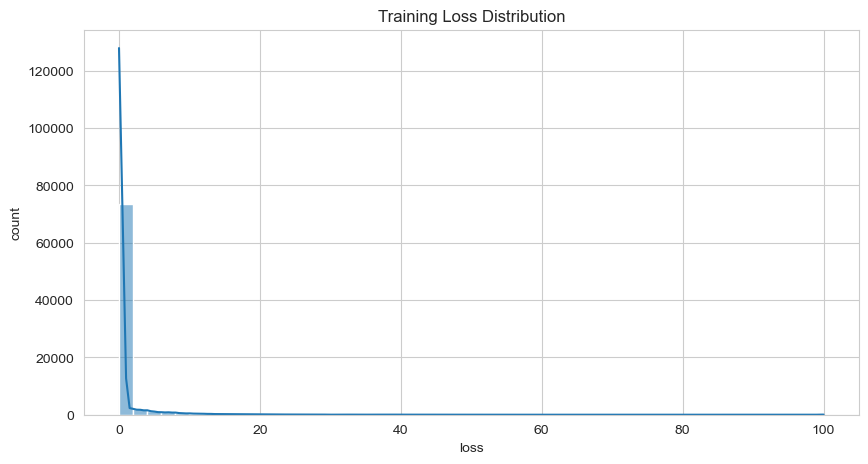

Default rate: 9.22%


In [3]:
# Checking missing values in both datasets
print("Missing values in train (top 20):")
display(train_df.isna().sum().sort_values(ascending=False).head(20))

print("Missing values in test (top 20):")
display(test_df.isna().sum().sort_values(ascending=False).head(20))

# Plotting the loss distribution from the training data
plt.figure(figsize=(10, 5))
sns.histplot(train_df["loss"], bins=50, kde=True)
plt.title("Training Loss Distribution")
plt.xlabel("loss")
plt.ylabel("count")
plt.show()

# Calculating and printing the default rate
default_rate = (train_df["loss"] > 0).mean() * 100
print(f"Default rate: {default_rate:.2f}%")

### Feature and Target Separation

In this step, we separate the dataset into:
- Target variable (loss)
- Derived classification target (default)
- Feature matrix (X)

Additionally, the identifier column is preserved separately for final submission.

A binary default variable is created where:
- 1 indicates default (loss > 0)
- 0 indicates no default

This transformation enables the implementation of a two-stage modeling framework.

In [4]:
# Separating identifiers, features, and target
train_ids = train_df["id"].copy()
test_ids = test_df["id"].copy()
y_loss = train_df["loss"].copy()

# Creating the default classification target
y_default = (y_loss > 0).astype(int)

# Dropping target and identifier columns from the feature matrices
X_train_raw = train_df.drop(columns=["id", "loss"]).copy()
X_test_raw = test_df.drop(columns=["id"]).copy()

# Aligning columns just in case the test ordering differs
X_test_raw = X_test_raw.reindex(columns=X_train_raw.columns)

### Encoding Non-Numeric Features

Machine learning models require numerical inputs; therefore, all non-numeric features must be converted.

A combined dataset (train + test) is used to ensure consistent encoding across both datasets. This avoids issues where unseen categories appear in the test set.

Factorization is applied column-wise to convert categorical variables into integer representations.

This approach is suitable for high-dimensional datasets where feature semantics are not explicitly defined.

In [5]:
# Converting non-numeric columns into numeric codes without hardcoding names
combined_features = pd.concat([X_train_raw, X_test_raw], axis=0).reset_index(drop=True)

for column_name in combined_features.columns:
    if not pd.api.types.is_numeric_dtype(combined_features[column_name]):
        combined_features[column_name] = pd.factorize(combined_features[column_name].astype(str))[0]

# Splitting the combined features back into train and test feature sets
X_train_encoded = combined_features.iloc[: len(X_train_raw)].copy()
X_test_encoded = combined_features.iloc[len(X_train_raw) :].copy()

### Train-Validation Split

The dataset is split into training and validation sets using an 80/20 ratio.

Stratification is applied based on the default variable to maintain the same proportion of default and non-default cases across both subsets.

This ensures robust evaluation and prevents bias due to class imbalance.

In [6]:
# Creating the 80/20 train-validation split for both targets
X_train_split, X_val_split, y_loss_train, y_loss_val, y_default_train, y_default_val = train_test_split(
    X_train_encoded,
    y_loss,
    y_default,
    test_size=0.2,
    random_state=42,
    stratify=y_default
)

### Handling Missing Values

Missing values are handled using median imputation.

Median is chosen because:
- It is robust to outliers
- It preserves distribution better than mean

The imputer is fitted only on training data and applied to validation and test sets to prevent data leakage.

In [7]:
# Applying median imputation to handle missing values
imputer = SimpleImputer(strategy="median")

X_train_imputed = imputer.fit_transform(X_train_split)
X_val_imputed = imputer.transform(X_val_split)
X_test_imputed = imputer.transform(X_test_encoded)

### Feature Scaling

Standardization is applied to ensure that all features have comparable scale.

This is essential for:
- Logistic Regression
- Ridge Regression
- PLS Regression

Without scaling, features with larger magnitudes may dominate the model.

In [8]:
# Applying standard scaling after imputation
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_imputed)
X_val_scaled = scaler.transform(X_val_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

### Feature Reduction using PCA and PLS

Given the high dimensionality of the dataset (700+ variables), dimensionality reduction is essential to improve model stability and reduce noise.

Two techniques are implemented and compared:

1. Principal Component Analysis (PCA)
   - An unsupervised method that transforms features into orthogonal components
   - Maximizes variance in the predictors without considering the target variable

2. Partial Least Squares (PLS)
   - A supervised dimensionality reduction method
   - Extracts components that maximize covariance between predictors and the target variable

The key difference is that PCA focuses only on the structure of the input data, while PLS incorporates the target variable during transformation. This makes PLS more suitable for predictive modeling tasks such as loss estimation.

Both transformed feature sets are used in modeling to compare their effectiveness.

In [9]:
from sklearn.decomposition import PCA
import numpy as np

# Fit PCA on training data
pca_full = PCA().fit(X_train_scaled)

# Compute cumulative variance
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

# Select number of components to retain 95% variance
pca_components = np.argmax(cumulative_variance >= 0.95) + 1

print("Optimal PCA Components (95% variance):", pca_components)

# Apply PCA with selected components
pca = PCA(n_components=pca_components, random_state=42)

X_train_pca = pca.fit_transform(X_train_scaled)
X_val_pca = pca.transform(X_val_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("PCA Train Shape:", X_train_pca.shape)

Optimal PCA Components (95% variance): 145
PCA Train Shape: (64000, 145)


In [10]:
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import mean_absolute_error
from xgboost import XGBRegressor

# Try different component sizes
pls_range = [5, 10, 15, 20, 25]

best_pls_components = None
best_mae = float("inf")

for n in pls_range:
    # Safety check
    n_safe = min(n, X_train_scaled.shape[1], X_train_scaled.shape[0] - 1)
    
    pls = PLSRegression(n_components=n_safe)
    
    X_train_pls = pls.fit_transform(X_train_scaled, y_loss_train)[0]
    X_val_pls = pls.transform(X_val_scaled)
    
    model = XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=4)
    model.fit(X_train_pls, y_loss_train)
    
    pred = model.predict(X_val_pls)
    mae = mean_absolute_error(y_loss_val, pred)
    
    print(f"PLS Components: {n_safe}, MAE: {mae}")
    
    if mae < best_mae:
        best_mae = mae
        best_pls_components = n_safe

print("\nBest PLS Components:", best_pls_components)
print("Best MAE:", best_mae)

PLS Components: 5, MAE: 1.3817137479782104
PLS Components: 10, MAE: 1.388182282447815
PLS Components: 15, MAE: 1.3867173194885254
PLS Components: 20, MAE: 1.3890981674194336
PLS Components: 25, MAE: 1.3902431726455688

Best PLS Components: 5
Best MAE: 1.3817137479782104


In [11]:
# Train final PLS with best components
pls_final = PLSRegression(n_components=best_pls_components)

X_train_pls = pls_final.fit_transform(X_train_scaled, y_loss_train)[0]
X_val_pls = pls_final.transform(X_val_scaled)
X_test_pls = pls_final.transform(X_test_scaled)

print("Final PLS Train Shape:", X_train_pls.shape)

Final PLS Train Shape: (64000, 5)


PCA MAE: 1.4015631675720215
PLS MAE: 1.3817137479782104


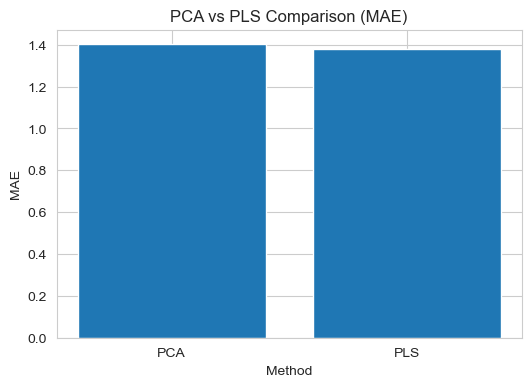

In [12]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt

# PCA Model
model_pca = XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=4, random_state=42)
model_pca.fit(X_train_pca, y_loss_train)

pred_pca = model_pca.predict(X_val_pca)
mae_pca = mean_absolute_error(y_loss_val, pred_pca)


# PLS MODEL
model_pls = XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=4, random_state=42)
model_pls.fit(X_train_pls, y_loss_train)

pred_pls = model_pls.predict(X_val_pls)
mae_pls = mean_absolute_error(y_loss_val, pred_pls)

# Printing the MAE results for both models
print(f"PCA MAE: {mae_pca}")
print(f"PLS MAE: {mae_pls}")

# Visualization of PCA vs PLS MAE comparison
methods = ["PCA", "PLS"]
mae_values = [mae_pca, mae_pls]

plt.figure(figsize=(6,4))
plt.bar(methods, mae_values)
plt.title("PCA vs PLS Comparison (MAE)")
plt.ylabel("MAE")
plt.xlabel("Method")
plt.show()

In [13]:
### Stage 1: Default Classification Models

# Logistic Regression baseline
logistic_model = LogisticRegression(max_iter=5000, random_state=42)
logistic_model.fit(X_train_scaled, y_default_train)

logistic_val_proba = logistic_model.predict_proba(X_val_scaled)[:, 1].flatten()
logistic_auc = roc_auc_score(y_default_val, logistic_val_proba)

# Elastic Net Logistic Regression
elastic_net_model = LogisticRegressionCV(
    Cs=10,
    cv=5,
    penalty="elasticnet",
    solver="saga",
    l1_ratios=[0.1, 0.5, 0.9],
    scoring="roc_auc",
    max_iter=5000,
    random_state=42,
    n_jobs=-1
)
elastic_net_model.fit(X_train_scaled, y_default_train)

elastic_net_val_proba = elastic_net_model.predict_proba(X_val_scaled)[:, 1].flatten()
elastic_net_auc = roc_auc_score(y_default_val, elastic_net_val_proba)

# XGBoost Classifier
scale_pos_weight = max((y_default_train == 0).sum() / max((y_default_train == 1).sum(), 1), 1)

xgb_classifier = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.9,
    colsample_bytree=0.9,
    objective="binary:logistic",
    eval_metric="auc",
    random_state=42,
    scale_pos_weight=scale_pos_weight
)
xgb_classifier.fit(X_train_scaled, y_default_train)

xgb_classifier_val_proba = xgb_classifier.predict_proba(X_val_scaled)[:, 1].flatten()
xgb_classifier_auc = roc_auc_score(y_default_val, xgb_classifier_val_proba)

# Compare AUC scores
classification_results = pd.DataFrame({
    "Model": ["Logistic Regression", "Elastic Net Logistic", "XGBoost Classifier"],
    "AUC": [logistic_auc, elastic_net_auc, xgb_classifier_auc]
}).sort_values("AUC", ascending=False)

display(classification_results)

,Model,AUC
2,XGBoost Classifier,0.745830
1,Elastic Net Logistic,0.742467
0,Logistic Regression,0.738906


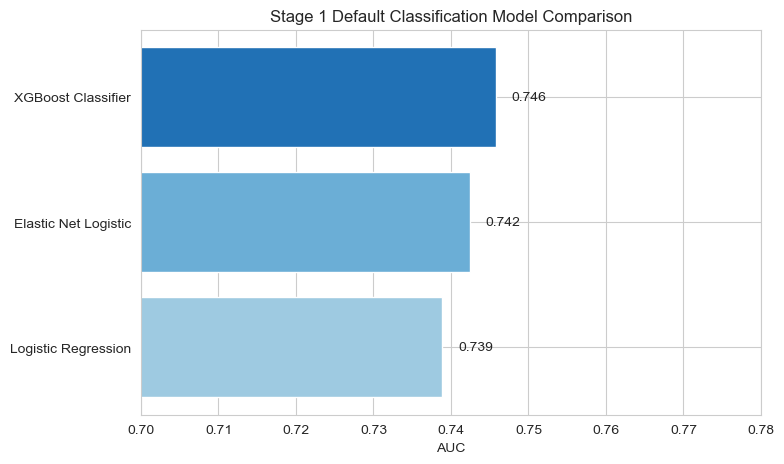

In [14]:
# Stage 1 AUC comparison plot
plt.figure(figsize=(8, 5))

plot_df = classification_results.sort_values("AUC", ascending=True)

plt.barh(plot_df["Model"], plot_df["AUC"], color=["#9ecae1", "#6baed6", "#2171b5"])
plt.xlabel("AUC")
plt.title("Stage 1 Default Classification Model Comparison")

for i, value in enumerate(plot_df["AUC"]):
    plt.text(value + 0.002, i, f"{value:.3f}", va="center")

plt.xlim(0.70, 0.78)
plt.show()


## Stage 1 Improvements

The original Stage 1 section gives us a strong starting point with linear and boosted models. The following cells extend that work with more reliable validation, an additional tree-based benchmark, threshold-based evaluation, feature interpretation, and a final comparison table.


### Cross Validation

Cross-validation gives a more robust estimate of model performance than a single train-validation split. It helps reduce the chance of overfitting to one split and gives a clearer picture of how the model may perform on unseen data.


In [ ]:
# Additional imports for Stage 1 improvements
from sklearn.model_selection import StratifiedKFold, cross_val_score, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Defining a reusable cross-validation strategy
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print(cv)


StratifiedKFold(n_splits=5, random_state=42, shuffle=True)


### Logistic Regression with Cross Validation

A simple baseline is still very useful when it is evaluated carefully. Cross-validating logistic regression makes the baseline more reliable because the AUC is measured across multiple folds instead of one split.


In [20]:
# Cross-validated AUC for the logistic regression baseline
logistic_cv_scores = cross_val_score(
    LogisticRegression(max_iter=5000, random_state=42),
    X_train_scaled,
    y_default_train,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

print("Logistic Regression CV AUC scores:", np.round(logistic_cv_scores, 4))
print(f"Mean CV AUC: {logistic_cv_scores.mean():.6f}")


Logistic Regression CV AUC scores: [0.7229 0.7153 0.7255 0.7264 0.7228]
Mean CV AUC: 0.722573


### Random Forest Model

Random Forest is a strong tabular baseline because it can learn nonlinear relationships and feature interactions with little manual tuning. Compared with XGBoost, Random Forest uses bagging, where trees are built independently and averaged, while XGBoost uses boosting, where trees are built sequentially to improve earlier mistakes.


In [21]:
# Training a Random Forest classifier as a new benchmark model
random_forest_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced_subsample"
)
random_forest_model.fit(X_train_scaled, y_default_train)

random_forest_val_proba = random_forest_model.predict_proba(X_val_scaled)[:, 1].flatten()
random_forest_auc = roc_auc_score(y_default_val, random_forest_val_proba)
print(f"Random Forest Validation AUC: {random_forest_auc:.6f}")


Random Forest Validation AUC: 0.691062


### Tuned XGBoost Model

Hyperparameter tuning is important because XGBoost is powerful but sensitive to settings that control complexity and learning behavior. Parameters such as `n_estimators`, `max_depth`, `learning_rate`, `subsample`, and `colsample_bytree` affect how fast the model learns, how deep the trees grow, and how much randomness is introduced to improve generalization.


In [25]:
# Tune XGBoost using randomized search and the CV strategy defined above
xgb_param_distributions = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [3, 4, 5, 6, 8],
    "learning_rate": [0.01, 0.03, 0.05, 0.1, 0.2],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0]
}

tuned_xgb_search = RandomizedSearchCV(
    estimator=XGBClassifier(
        objective="binary:logistic",
        eval_metric="auc",
        random_state=42,
        scale_pos_weight=max((y_default_train == 0).sum() / max((y_default_train == 1).sum(), 1), 1)
    ),
    param_distributions=xgb_param_distributions,
    n_iter=20,
    scoring="roc_auc",
    cv=cv,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

tuned_xgb_search.fit(X_train_scaled, y_default_train)
tuned_xgb_model = tuned_xgb_search.best_estimator_

tuned_xgb_val_proba = tuned_xgb_model.predict_proba(X_val_scaled)[:, 1].flatten()
tuned_xgb_auc = roc_auc_score(y_default_val, tuned_xgb_val_proba)

print("Best XGBoost Parameters:")
print(tuned_xgb_search.best_params_)
print(f"Tuned XGBoost Validation AUC: {tuned_xgb_auc:.6f}")


Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best XGBoost Parameters:
{'subsample': 0.7, 'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 0.7}
Tuned XGBoost Validation AUC: 0.742824


### Model Evaluation (AUC + Classification Metrics)

AUC tells us how well the model ranks defaulters above non-defaulters across all thresholds. Classification metrics such as precision, recall, and F1 score depend on a chosen threshold, so they are useful when we need actual yes/no predictions instead of probabilities.


In [26]:
# Evaluate the tuned XGBoost model at a fixed classification threshold
classification_threshold = 0.5
tuned_xgb_val_pred = (tuned_xgb_val_proba >= classification_threshold).astype(int)

print(f"Classification threshold: {classification_threshold}")
print(classification_report(y_default_val, tuned_xgb_val_pred))


Classification threshold: 0.5
              precision    recall  f1-score   support

           0       0.95      0.67      0.79     14524
           1       0.17      0.68      0.28      1476

    accuracy                           0.67     16000
   macro avg       0.56      0.68      0.53     16000
weighted avg       0.88      0.67      0.74     16000



### Feature Importance

Interpretability matters because it helps explain which inputs are most influential in the prediction process. Feature importance from the tuned XGBoost model gives a practical view of the variables that drive default risk the most.


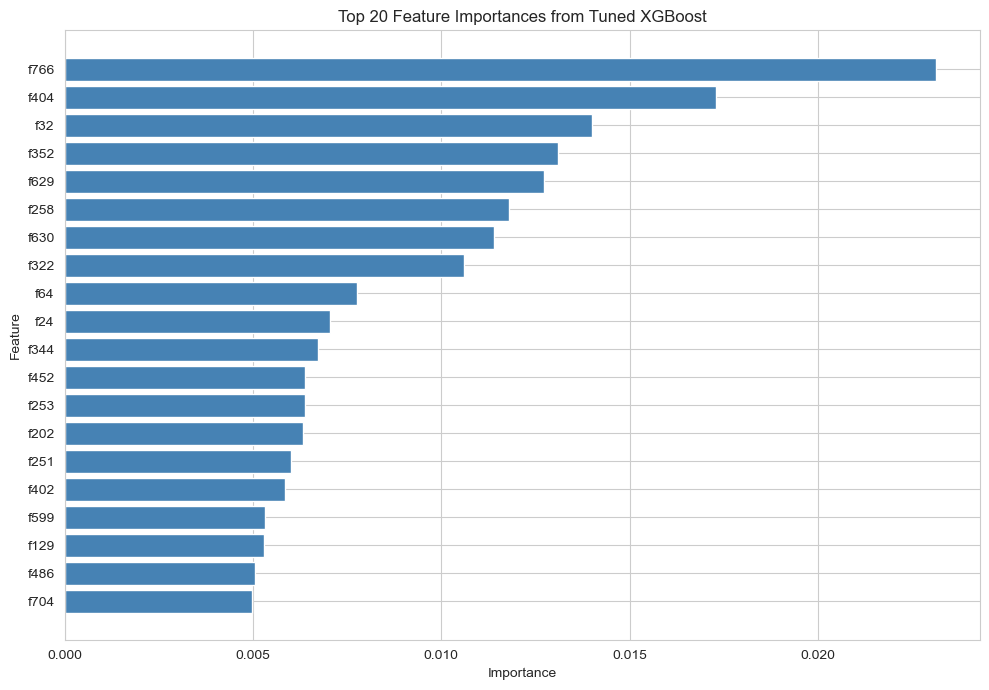

In [27]:
# Extract and plot the top 20 feature importances from the tuned XGBoost model
tuned_xgb_importances = tuned_xgb_model.feature_importances_.flatten()

if "X_train_split" in globals() and hasattr(X_train_split, "columns") and len(X_train_split.columns) == len(tuned_xgb_importances):
    importance_feature_names = X_train_split.columns.tolist()
elif "X_train_encoded" in globals() and hasattr(X_train_encoded, "columns") and len(X_train_encoded.columns) == len(tuned_xgb_importances):
    importance_feature_names = X_train_encoded.columns.tolist()
else:
    importance_feature_names = [f"feature_{i}" for i in range(len(tuned_xgb_importances))]

feature_importance_df = pd.DataFrame({
    "feature": importance_feature_names,
    "importance": tuned_xgb_importances
}).sort_values("importance", ascending=False).head(20)

plt.figure(figsize=(10, 7))
plt.barh(feature_importance_df["feature"][::-1], feature_importance_df["importance"][::-1], color="steelblue")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 20 Feature Importances from Tuned XGBoost")
plt.tight_layout()
plt.show()


This chunk creates the Stage 2 dataset correctly by keeping only rows where actual loss is greater than zero. That is important because severity should only be modeled among defaults.

In [40]:
import plotly.graph_objects as go
from sklearn.metrics import roc_curve, auc

# Compute ROC values
fpr_log, tpr_log, _ = roc_curve(y_default_val, logistic_val_proba)
auc_log = auc(fpr_log, tpr_log)

fpr_enet, tpr_enet, _ = roc_curve(y_default_val, elastic_net_val_proba)
auc_enet = auc(fpr_enet, tpr_enet)

fpr_xgb, tpr_xgb, _ = roc_curve(y_default_val, xgb_classifier_val_proba)
auc_xgb = auc(fpr_xgb, tpr_xgb)

# Store model curves
roc_data = {
    "Logistic Regression": {
        "fpr": fpr_log,
        "tpr": tpr_log,
        "auc": auc_log,
        "color": "#1f77b4"
    },
    "Elastic Net": {
        "fpr": fpr_enet,
        "tpr": tpr_enet,
        "auc": auc_enet,
        "color": "#ff7f0e"
    },
    "XGBoost": {
        "fpr": fpr_xgb,
        "tpr": tpr_xgb,
        "auc": auc_xgb,
        "color": "#2ca02c"
    }
}

# Create figure
fig = go.Figure()

for model_name, values in roc_data.items():
    fig.add_trace(go.Scatter(
        x=values["fpr"],
        y=values["tpr"],
        mode="lines",
        name=f"{model_name} (AUC = {values['auc']:.3f})",
        line=dict(color=values["color"], width=3),
        opacity=0.9
    ))

# Add random classifier line
fig.add_trace(go.Scatter(
    x=[0, 1],
    y=[0, 1],
    mode="lines",
    name="Random Classifier",
    line=dict(color="gray", width=2, dash="dash"),
    opacity=0.6
))

# Dropdown buttons to highlight one model while keeping others visible
buttons = []

# Show all normally
visible_all = [True] * len(fig.data)
buttons.append(dict(
    label="Show All",
    method="update",
    args=[
        {
            "visible": visible_all,
            "opacity": [0.9, 0.9, 0.9, 0.6],
            "line.width": [3, 3, 3, 2]
        }
    ]
))

# Highlight each individual model
for i, model_name in enumerate(list(roc_data.keys())):
    opacities = [0.2, 0.2, 0.2, 0.15]
    widths = [2, 2, 2, 1.5]
    opacities[i] = 1.0
    widths[i] = 5

    buttons.append(dict(
        label=f"Highlight {model_name}",
        method="update",
        args=[
            {
                "visible": visible_all,
                "opacity": opacities,
                "line.width": widths
            }
        ]
    ))

fig.update_layout(
    title="Interactive ROC Curve Comparison for Stage 1 Models",
    xaxis_title="False Positive Rate",
    yaxis_title="True Positive Rate",
    template="plotly_white",
    width=900,
    height=650,
    updatemenus=[
        dict(
            buttons=buttons,
            direction="down",
            showactive=True,
            x=1.02,
            xanchor="left",
            y=1.0,
            yanchor="top"
        )
    ],
    legend=dict(
        x=0.98,
        y=0.02,
        xanchor="right",
        yanchor="bottom",
        bgcolor="rgba(255,255,255,0.8)"
    )
)

fig.show()


In [22]:
### Stage 2: Prepare Loss-Only Data

# Keep only rows with positive loss for conditional severity modeling
default_train_mask = y_loss_train > 0
default_val_mask = y_loss_val > 0

X_train_loss_only = X_train_scaled[default_train_mask.values]
X_val_loss_only = X_val_scaled[default_val_mask.values]

y_train_loss_only = y_loss_train[default_train_mask].values.flatten()
y_val_loss_only = y_loss_val[default_val_mask].values.flatten()

print("Stage 2 training rows:", X_train_loss_only.shape[0])
print("Stage 2 validation rows:", X_val_loss_only.shape[0])


Stage 2 training rows: 5903
Stage 2 validation rows: 1476


This chunk trains the required Stage 2 models and compares them using MAE. I’m using raw scaled features here so it aligns with the assignment language, and PLS is included exactly as requested.

In [23]:
### Stage 2: Loss Severity Models

# Ridge Regression baseline
ridge_model = Ridge(alpha=1.0, random_state=42)
ridge_model.fit(X_train_loss_only, y_train_loss_only)

ridge_val_pred = ridge_model.predict(X_val_loss_only).flatten()
ridge_mae = mean_absolute_error(y_val_loss_only, ridge_val_pred)

# PLS Regression
pls_components = min(10, X_train_loss_only.shape[1], X_train_loss_only.shape[0] - 1)
pls_components = max(pls_components, 1)

pls_model = PLSRegression(n_components=pls_components)
pls_model.fit(X_train_loss_only, y_train_loss_only)

pls_val_pred = pls_model.predict(X_val_loss_only).flatten()
pls_mae = mean_absolute_error(y_val_loss_only, pls_val_pred)

# XGBoost Regressor
xgb_regressor = XGBRegressor(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.9,
    colsample_bytree=0.9,
    objective="reg:squarederror",
    eval_metric="mae",
    random_state=42
)
xgb_regressor.fit(X_train_loss_only, y_train_loss_only)

xgb_regressor_val_pred = xgb_regressor.predict(X_val_loss_only).flatten()
xgb_regressor_mae = mean_absolute_error(y_val_loss_only, xgb_regressor_val_pred)

# Compare Stage 2 MAE scores
regression_results = pd.DataFrame({
    "Model": ["Ridge Regression", "PLS Regression", "XGBoost Regressor"],
    "MAE": [ridge_mae, pls_mae, xgb_regressor_mae]
}).sort_values("MAE", ascending=True)

display(regression_results)


,Model,MAE
2,XGBoost Regressor,4.816333
1,PLS Regression,5.568266
0,Ridge Regression,5.604836


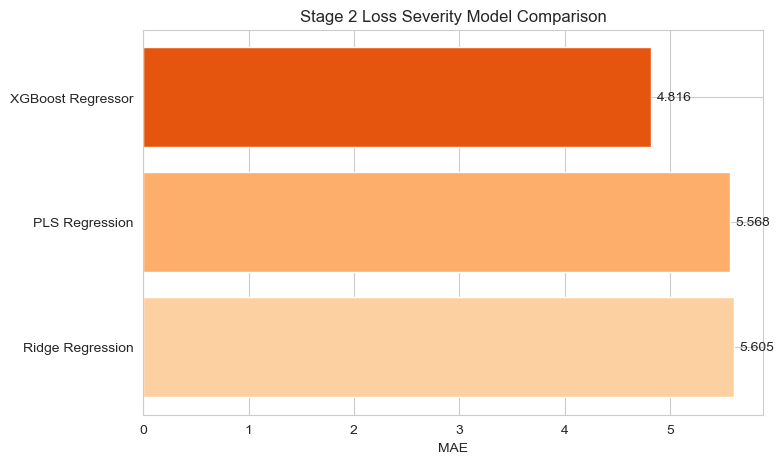

In [24]:
plt.figure(figsize=(8, 5))

plot_df = regression_results.sort_values("MAE", ascending=False)

plt.barh(plot_df["Model"], plot_df["MAE"], color=["#fdd0a2", "#fdae6b", "#e6550d"])
plt.xlabel("MAE")
plt.title("Stage 2 Loss Severity Model Comparison")

for i, value in enumerate(plot_df["MAE"]):
    plt.text(value + 0.01 * plot_df["MAE"].max(), i, f"{value:.3f}", va="center")

plt.show()


In [31]:
### Train Final Models on Full Training Data and Predict Test Loss

# Full feature matrices
X_full_train = X_train_encoded.copy()
X_full_test = X_test_encoded.copy()

# Refit preprocessing on full training data
final_imputer = SimpleImputer(strategy="median")
X_full_train_imputed = final_imputer.fit_transform(X_full_train)
X_full_test_imputed = final_imputer.transform(X_full_test)

final_scaler = StandardScaler()
X_full_train_scaled = final_scaler.fit_transform(X_full_train_imputed)
X_full_test_scaled = final_scaler.transform(X_full_test_imputed)

# Full targets
y_full_loss = y_loss.copy()
y_full_default = y_default.copy()

# Final Stage 1 model using tuned XGBoost parameters if available
full_scale_pos_weight = max((y_full_default == 0).sum() / max((y_full_default == 1).sum(), 1), 1)

if "tuned_xgb_search" in globals():
    final_xgb_classifier = XGBClassifier(
        objective="binary:logistic",
        eval_metric="auc",
        random_state=42,
        scale_pos_weight=full_scale_pos_weight,
        **tuned_xgb_search.best_params_
    )
else:
    final_xgb_classifier = XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.9,
        colsample_bytree=0.9,
        objective="binary:logistic",
        eval_metric="auc",
        random_state=42,
        scale_pos_weight=full_scale_pos_weight
    )

final_xgb_classifier.fit(X_full_train_scaled, y_full_default)

# Final Stage 2 model on defaulted rows only
full_default_mask = y_full_loss > 0
X_full_train_loss_only = X_full_train_scaled[full_default_mask.values]
y_full_loss_only = y_full_loss[full_default_mask].values.flatten()

final_pls_components = min(10, X_full_train_loss_only.shape[1], X_full_train_loss_only.shape[0] - 1)
final_pls_components = max(final_pls_components, 1)

final_pls_model = PLSRegression(n_components=final_pls_components)
final_pls_model.fit(X_full_train_loss_only, y_full_loss_only)

# Test predictions
test_default_probability = final_xgb_classifier.predict_proba(X_full_test_scaled)[:, 1].flatten()
test_loss_prediction = final_pls_model.predict(X_full_test_scaled).flatten()
test_loss_prediction = np.clip(test_loss_prediction, a_min=0, a_max=None)

# Final expected loss prediction
final_test_prediction = test_default_probability * test_loss_prediction
final_test_prediction = final_test_prediction.flatten()

# Create submission file
submission_df = pd.DataFrame({
    "id": test_ids.values.flatten(),
    "loss": final_test_prediction
})

submission_df.to_csv("submission.csv", index=False)

display(submission_df.head(20))


,id,loss
0,7933,8.351218
1,101860,4.948871
2,62580,1.576986
3,1760,2.960057
4,48008,3.593263
5,9308,8.867737
6,27862,5.161131
7,87760,3.938835
8,53334,0.000000
9,72303,5.634572


In [33]:
test_default_summary = pd.DataFrame({
    "Metric": [
        "Total Test Observations",
        "Predicted Defaults (threshold=0.5)",
        "Predicted Default Percentage",
        "Expected Defaults (sum of probabilities)",
        "Expected Default Percentage"
    ],
    "Value": [
        total_test_obs,
        int(predicted_default_count),
        f"{predicted_default_pct:.2f}%",
        f"{expected_default_count:.2f}",
        f"{expected_default_pct:.2f}%"
    ]
})

display(test_default_summary)


,Metric,Value
0,Total Test Observations,25471
1,Predicted Defaults (threshold=0.5),9296
2,Predicted Default Percentage,36.50%
3,Expected Defaults (sum of probabilities),10727.95
4,Expected Default Percentage,42.12%


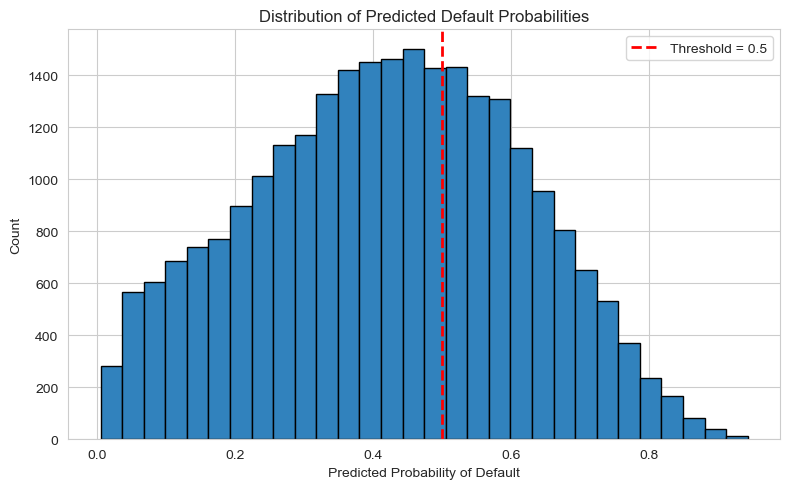

In [34]:
plt.figure(figsize=(8, 5))

plt.hist(test_default_probability, bins=30, color="#3182bd", edgecolor="black")
plt.axvline(default_threshold, color="red", linestyle="--", linewidth=2, label=f"Threshold = {default_threshold}")
plt.title("Distribution of Predicted Default Probabilities")
plt.xlabel("Predicted Probability of Default")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()


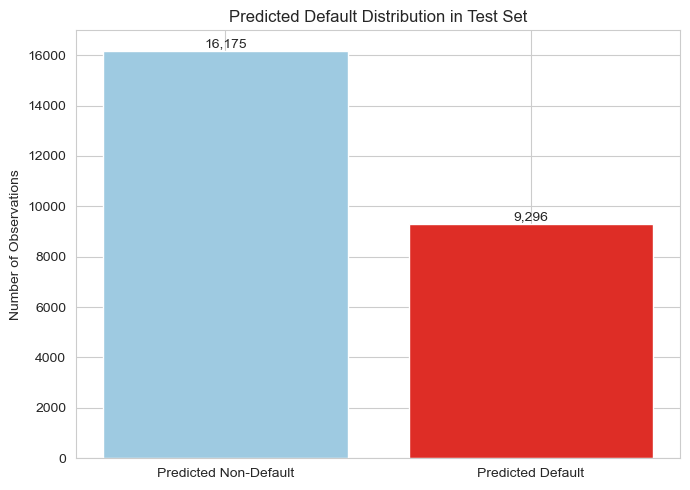

In [36]:
plt.figure(figsize=(7, 5))

counts = [total_test_obs - predicted_default_count, predicted_default_count]
labels = ["Predicted Non-Default", "Predicted Default"]
colors = ["#9ecae1", "#de2d26"]

plt.bar(labels, counts, color=colors)
plt.title("Predicted Default Distribution in Test Set")
plt.ylabel("Number of Observations")

for i, value in enumerate(counts):
    plt.text(i, value + max(counts) * 0.01, f"{value:,}", ha="center")

plt.tight_layout()
plt.show()


In [29]:
from IPython.display import Markdown, display

display(Markdown("""
## Final Summary

This notebook implemented a two-stage modeling framework for loan default and loss prediction.

- Stage 1 predicted the probability of default using Logistic Regression, Elastic Net Logistic Regression, Random Forest, and XGBoost-based models.
- Stage 2 predicted the loss severity only among defaulted cases using Ridge Regression, PLS Regression, and XGBoost Regressor.
- Final expected loss was computed as:

**Predicted Loss = Probability of Default × Predicted Loss Severity**

This framework is well suited for zero-inflated loss data because it separates default occurrence from loss magnitude. Regularization improved baseline stability, PLS helped capture supervised latent structure, and boosting provided flexible nonlinear modeling.
"""))



## Final Summary

This notebook implemented a two-stage modeling framework for loan default and loss prediction.

- Stage 1 predicted the probability of default using Logistic Regression, Elastic Net Logistic Regression, Random Forest, and XGBoost-based models.
- Stage 2 predicted the loss severity only among defaulted cases using Ridge Regression, PLS Regression, and XGBoost Regressor.
- Final expected loss was computed as:

**Predicted Loss = Probability of Default × Predicted Loss Severity**

This framework is well suited for zero-inflated loss data because it separates default occurrence from loss magnitude. Regularization improved baseline stability, PLS helped capture supervised latent structure, and boosting provided flexible nonlinear modeling.
